# Car Diagnostics Audio Dataset - Exploration

This notebook explores the [Car Diagnostics Dataset](https://www.kaggle.com/datasets/malakragaie/car-diagnostics-dataset) from Kaggle.

The dataset contains audio recordings of vehicles under three operational states:
- **Braking** — normal brakes vs. worn-out brakes
- **Idle** — normal engine idle vs. faults (low oil, power steering, serpentine belt) plus combined-fault recordings
- **Start-Up** — normal engine start-up vs. faults (bad ignition, dead battery)

Goal: understand the structure, class balance, and audio characteristics before building any classification models.

In [1]:
# --- Cell 1: Imports ---

import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

DATASET_ROOT = Path("car_diagnostics_dataset")
print(f"Dataset root exists: {DATASET_ROOT.exists()}")

Dataset root exists: True


In [2]:
# --- Cell 2: Inventory — scan directory tree and build a file catalog ---

records = []
for wav_path in sorted(DATASET_ROOT.rglob("*.wav")):
    parts = wav_path.relative_to(DATASET_ROOT).parts
    state = parts[0]                    # e.g. 'braking state'
    # For the 'combined' sub-folder under idle, capture the full sub-path
    condition = "/".join(parts[1:-1])   # e.g. 'normal_brakes' or 'combined/no oil_serpentine belt'
    records.append({
        "path": str(wav_path),
        "filename": wav_path.name,
        "state": state,
        "condition": condition,
    })

df_files = pd.DataFrame(records)
print(f"Total WAV files: {len(df_files)}")
print(f"\nOperational states: {df_files['state'].unique().tolist()}")
print(f"\nConditions per state:")
for state, grp in df_files.groupby("state"):
    print(f"  {state}:")
    for cond, sub in grp.groupby("condition"):
        print(f"    {cond}: {len(sub)} files")

df_files.head()

Total WAV files: 1386

Operational states: ['braking state', 'idle state', 'startup state']

Conditions per state:
  braking state:
    normal_brakes: 77 files
    worn_out_brakes: 76 files
  idle state:
    combined/no oil_serpentine belt: 107 files
    combined/power steering combined_no oil: 107 files
    combined/power steering combined_no oil_serpentine belt: 107 files
    combined/power steering combined_serpentine belt: 116 files
    low_oil: 107 files
    normal_engine_idle: 264 files
    power_steering: 129 files
    serpentine_belt: 116 files
  startup state:
    bad_ignition: 62 files
    dead_battery: 57 files
    normal_engine_startup: 61 files


,path,filename,state,condition
0,car_diagnostics_dataset/braking state/normal_b...,normal_brakes_1.wav,braking state,normal_brakes
1,car_diagnostics_dataset/braking state/normal_b...,normal_brakes_10.wav,braking state,normal_brakes
2,car_diagnostics_dataset/braking state/normal_b...,normal_brakes_11.wav,braking state,normal_brakes
3,car_diagnostics_dataset/braking state/normal_b...,normal_brakes_12.wav,braking state,normal_brakes
4,car_diagnostics_dataset/braking state/normal_b...,normal_brakes_13.wav,braking state,normal_brakes


In [3]:
# --- Cell 3: Audio properties — sample rate, duration, channels ---
# Read metadata for every file (fast — only reads headers, not full audio)

durations = []
sample_rates = []
channels_list = []

for path_str in df_files["path"]:
    info = sf.info(path_str)
    durations.append(info.duration)
    sample_rates.append(info.samplerate)
    channels_list.append(info.channels)

df_files["duration_s"] = durations
df_files["sample_rate"] = sample_rates
df_files["channels"] = channels_list

print("=== Audio Properties Summary ===")
print(f"\nSample rates present:  {sorted(df_files['sample_rate'].unique())}")
print(f"Channel counts present: {sorted(df_files['channels'].unique())}")
print(f"\nDuration statistics (seconds):")
print(df_files["duration_s"].describe().to_string())
print(f"\nDuration stats by state:")
print(df_files.groupby("state")["duration_s"].describe().round(2).to_string())

=== Audio Properties Summary ===

Sample rates present:  [np.int64(24000), np.int64(44100), np.int64(48000)]
Channel counts present: [np.int64(1)]

Duration statistics (seconds):
count    1386.000000
mean        1.525974
std         0.067256
min         1.500000
25%         1.500000
50%         1.500000
75%         1.500000
max         1.700000

Duration stats by state:
                count  mean  std  min  25%  50%  75%  max
state                                                    
braking state   153.0   1.5  0.0  1.5  1.5  1.5  1.5  1.5
idle state     1053.0   1.5  0.0  1.5  1.5  1.5  1.5  1.5
startup state   180.0   1.7  0.0  1.7  1.7  1.7  1.7  1.7


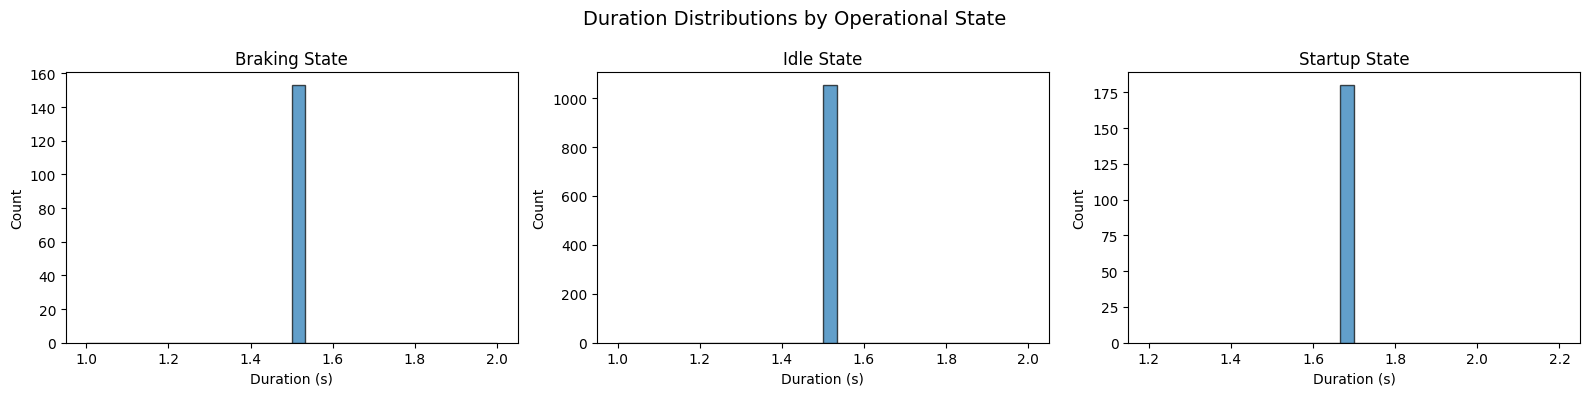

In [4]:
# --- Cell 4: Duration distribution histograms ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
states = sorted(df_files["state"].unique())

for ax, state in zip(axes, states):
    subset = df_files[df_files["state"] == state]
    ax.hist(subset["duration_s"], bins=30, edgecolor="black", alpha=0.7)
    ax.set_title(state.title())
    ax.set_xlabel("Duration (s)")
    ax.set_ylabel("Count")

fig.suptitle("Duration Distributions by Operational State", fontsize=14)
plt.tight_layout()
plt.show()

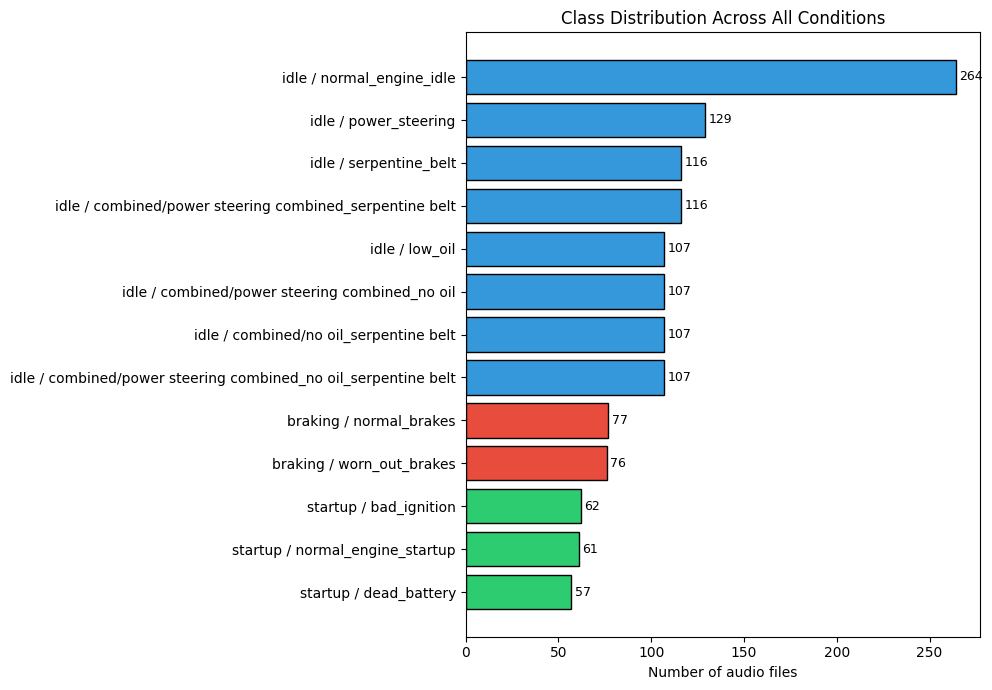

In [5]:
# --- Cell 5: Class distribution bar chart ---

class_counts = df_files.groupby(["state", "condition"]).size().reset_index(name="count")
class_counts["label"] = class_counts["state"].str.replace(" state", "") + " / " + class_counts["condition"]
class_counts = class_counts.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
palette = {"braking": "#e74c3c", "idle": "#3498db", "startup": "#2ecc71"}
colors = []
for _, row in class_counts.iterrows():
    key = row["state"].replace(" state", "")
    colors.append(palette.get(key, "#95a5a6"))

ax.barh(class_counts["label"], class_counts["count"], color=colors, edgecolor="black")
ax.set_xlabel("Number of audio files")
ax.set_title("Class Distribution Across All Conditions")
for i, v in enumerate(class_counts["count"]):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

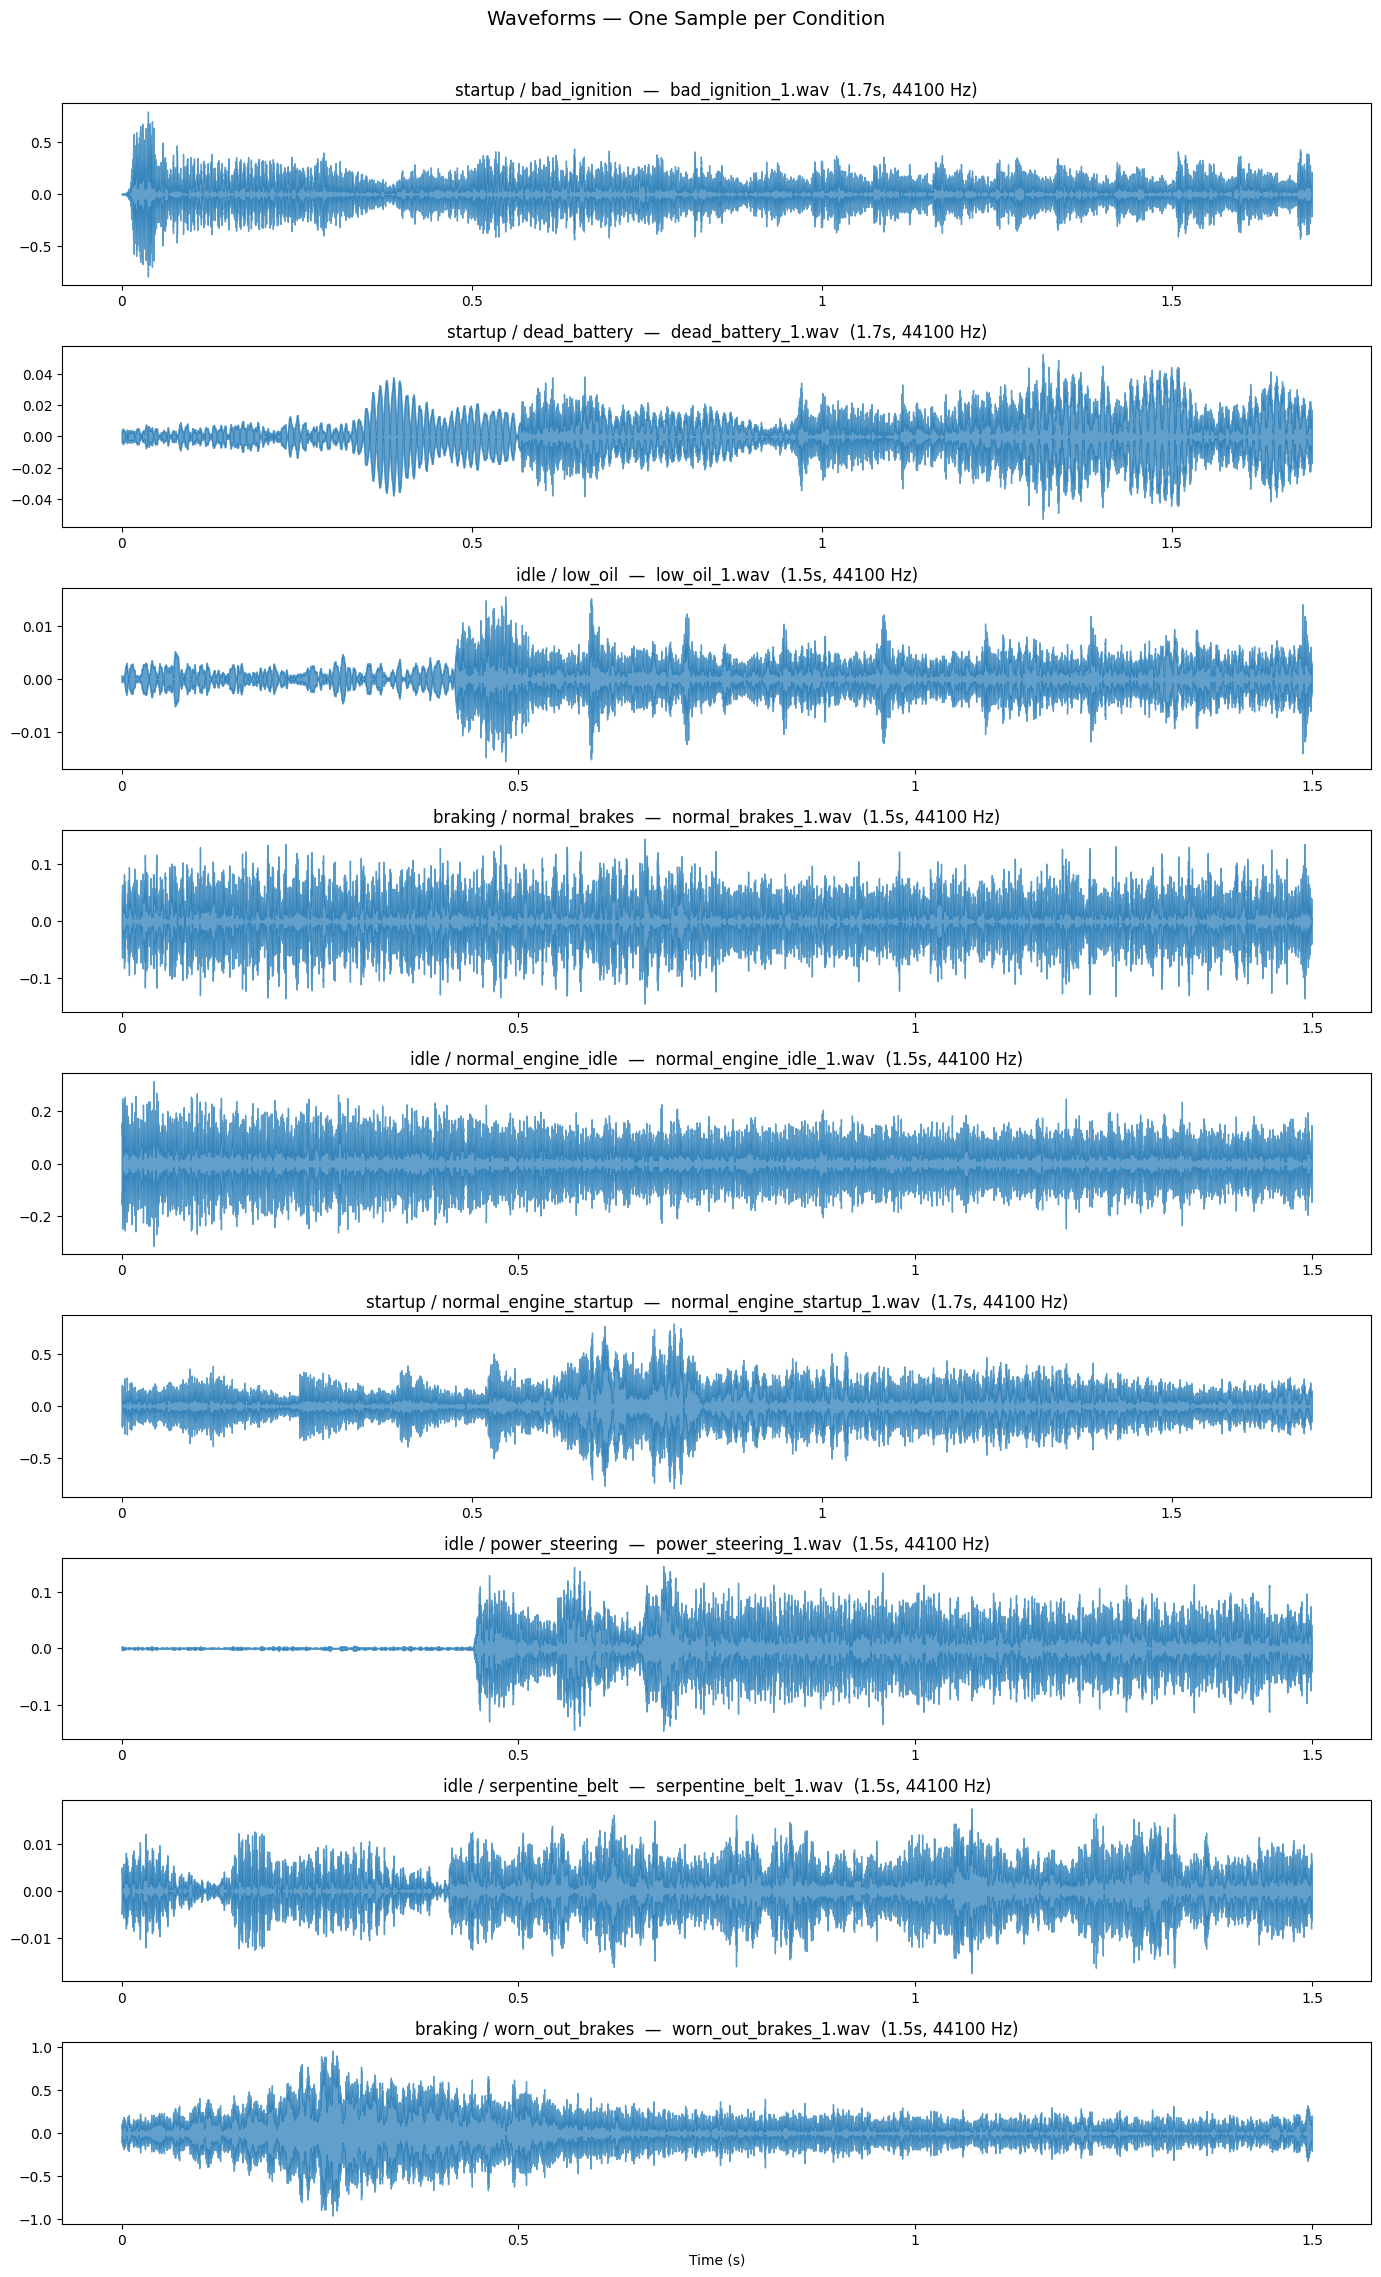

In [6]:
# --- Cell 6: Waveform visualization — one sample per top-level condition ---
# Pick one representative file from each non-combined condition

# Filter to non-combined conditions for cleaner comparison
top_level = df_files[~df_files["condition"].str.startswith("combined")]
conditions = sorted(top_level["condition"].unique())

fig, axes = plt.subplots(len(conditions), 1, figsize=(14, 2.5 * len(conditions)))

for ax, cond in zip(axes, conditions):
    sample_row = top_level[top_level["condition"] == cond].iloc[0]
    y, sr = librosa.load(sample_row["path"], sr=None)
    librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.7)
    state_label = sample_row["state"].replace(" state", "")
    ax.set_title(f"{state_label} / {cond}  \u2014  {sample_row['filename']}  ({sample_row['duration_s']:.1f}s, {sr} Hz)")
    ax.set_xlabel("")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Waveforms \u2014 One Sample per Condition", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

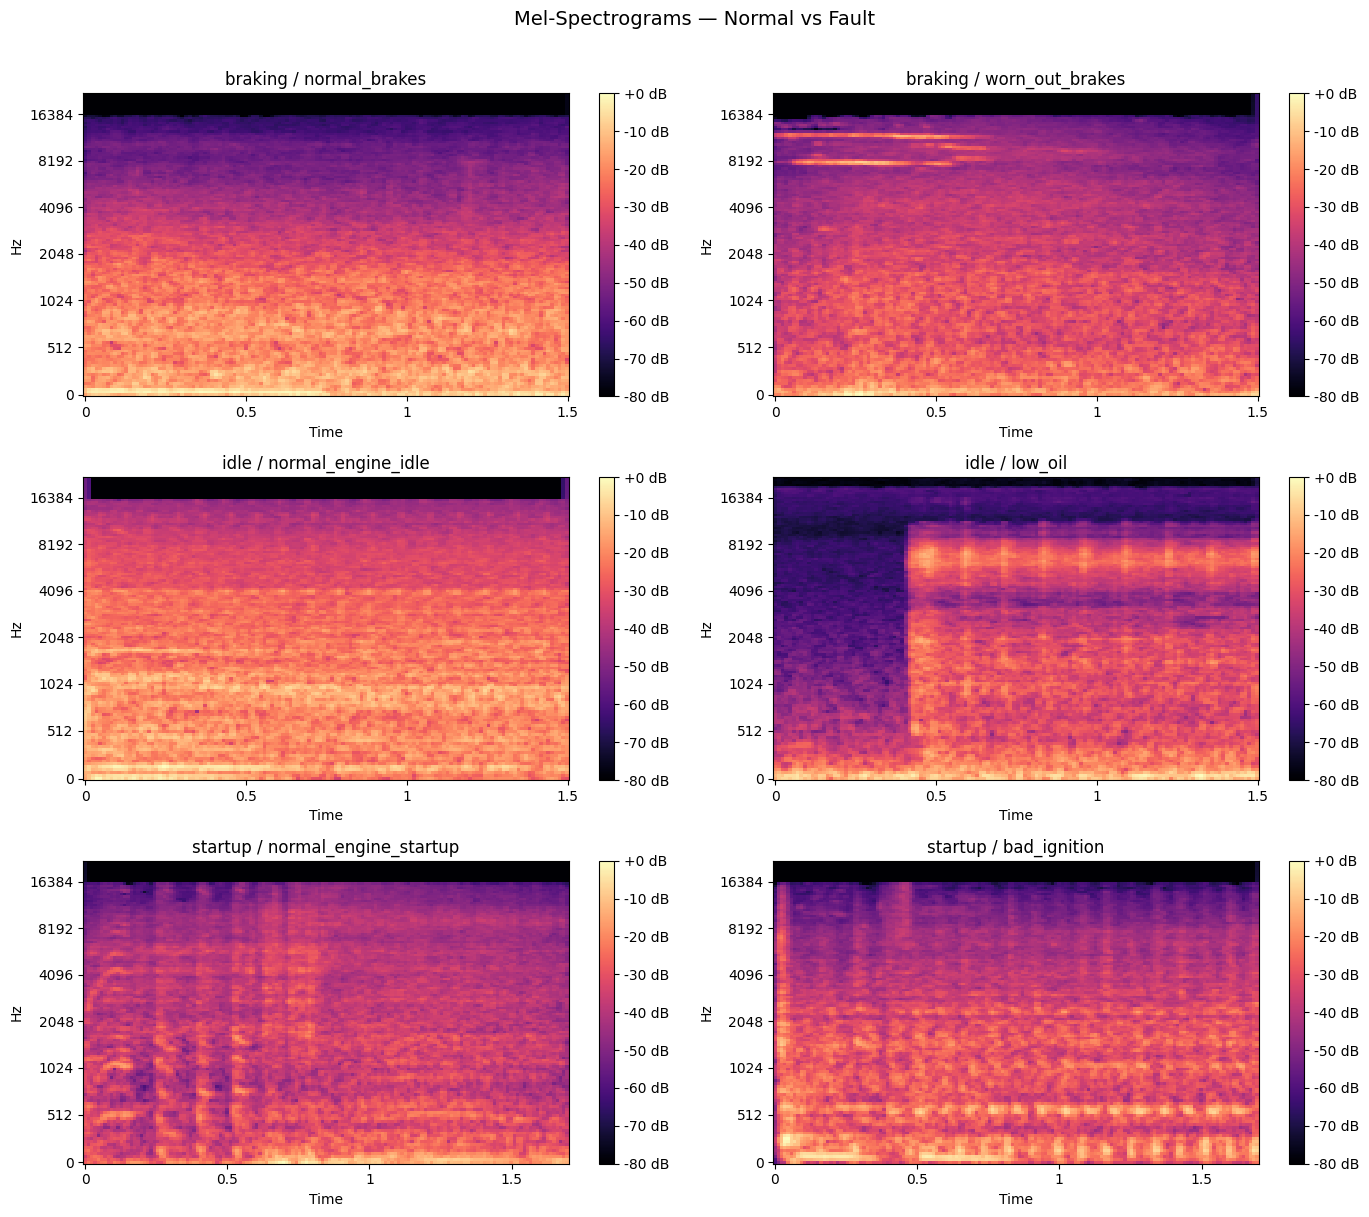

In [7]:
# --- Cell 7: Mel-spectrograms — side-by-side normal vs fault per state ---

comparisons = [
    ("braking state", "normal_brakes", "worn_out_brakes"),
    ("idle state",    "normal_engine_idle", "low_oil"),
    ("startup state", "normal_engine_startup", "bad_ignition"),
]

fig, axes = plt.subplots(len(comparisons), 2, figsize=(14, 4 * len(comparisons)))

for row_idx, (state, normal_cond, fault_cond) in enumerate(comparisons):
    for col_idx, cond in enumerate([normal_cond, fault_cond]):
        sample = df_files[(df_files["state"] == state) & (df_files["condition"] == cond)].iloc[0]
        y, sr = librosa.load(sample["path"], sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        ax = axes[row_idx, col_idx]
        img = librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="mel", ax=ax, cmap="magma")
        ax.set_title(f"{state.replace(' state','')} / {cond}")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")

fig.suptitle("Mel-Spectrograms \u2014 Normal vs Fault", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# --- Cell 8: Aggregate audio features — RMS energy, spectral centroid, ZCR ---
# Compute lightweight features for every file to see if classes are separable

feature_records = []
for _, row in df_files.iterrows():
    y, sr = librosa.load(row["path"], sr=22050)  # resample to common rate
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

    feature_records.append({
        "state": row["state"],
        "condition": row["condition"],
        "rms_mean": rms.mean(),
        "rms_std": rms.std(),
        "zcr_mean": zcr.mean(),
        "zcr_std": zcr.std(),
        "centroid_mean": centroid.mean(),
        "centroid_std": centroid.std(),
        "bandwidth_mean": bandwidth.mean(),
        "bandwidth_std": bandwidth.std(),
    })

df_features = pd.DataFrame(feature_records)
print("=== Mean Features by Condition ===")
summary = df_features.groupby(["state", "condition"]).mean(numeric_only=True).round(4)
print(summary.to_string())

=== Mean Features by Condition ===
                                                                       rms_mean  rms_std  zcr_mean  zcr_std  centroid_mean  centroid_std  bandwidth_mean  bandwidth_std
state         condition                                                                                                                                                
braking state normal_brakes                                              0.0679   0.0194    0.0932   0.0193      2036.6841      234.4238       2266.4555       154.7110
              worn_out_brakes                                            0.0739   0.0433    0.1688   0.0823      2332.4395      596.0830       2383.8683       332.2194
idle state    combined/no oil_serpentine belt                            0.1775   0.0273    0.2484   0.0446      3657.3059      349.7339       2764.1872       137.5404
              combined/power steering combined_no oil                    0.1759   0.0293    0.1719   0.0303      3068.0120   

/tmp/ipykernel_66079/1824553124.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_sorted, patch_artist=True, vert=False)
/tmp/ipykernel_66079/1824553124.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_sorted, patch_artist=True, vert=False)
/tmp/ipykernel_66079/1824553124.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_sorted, patch_artist=True, vert=False)
/tmp/ipykernel_66079/1824553124.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Mat

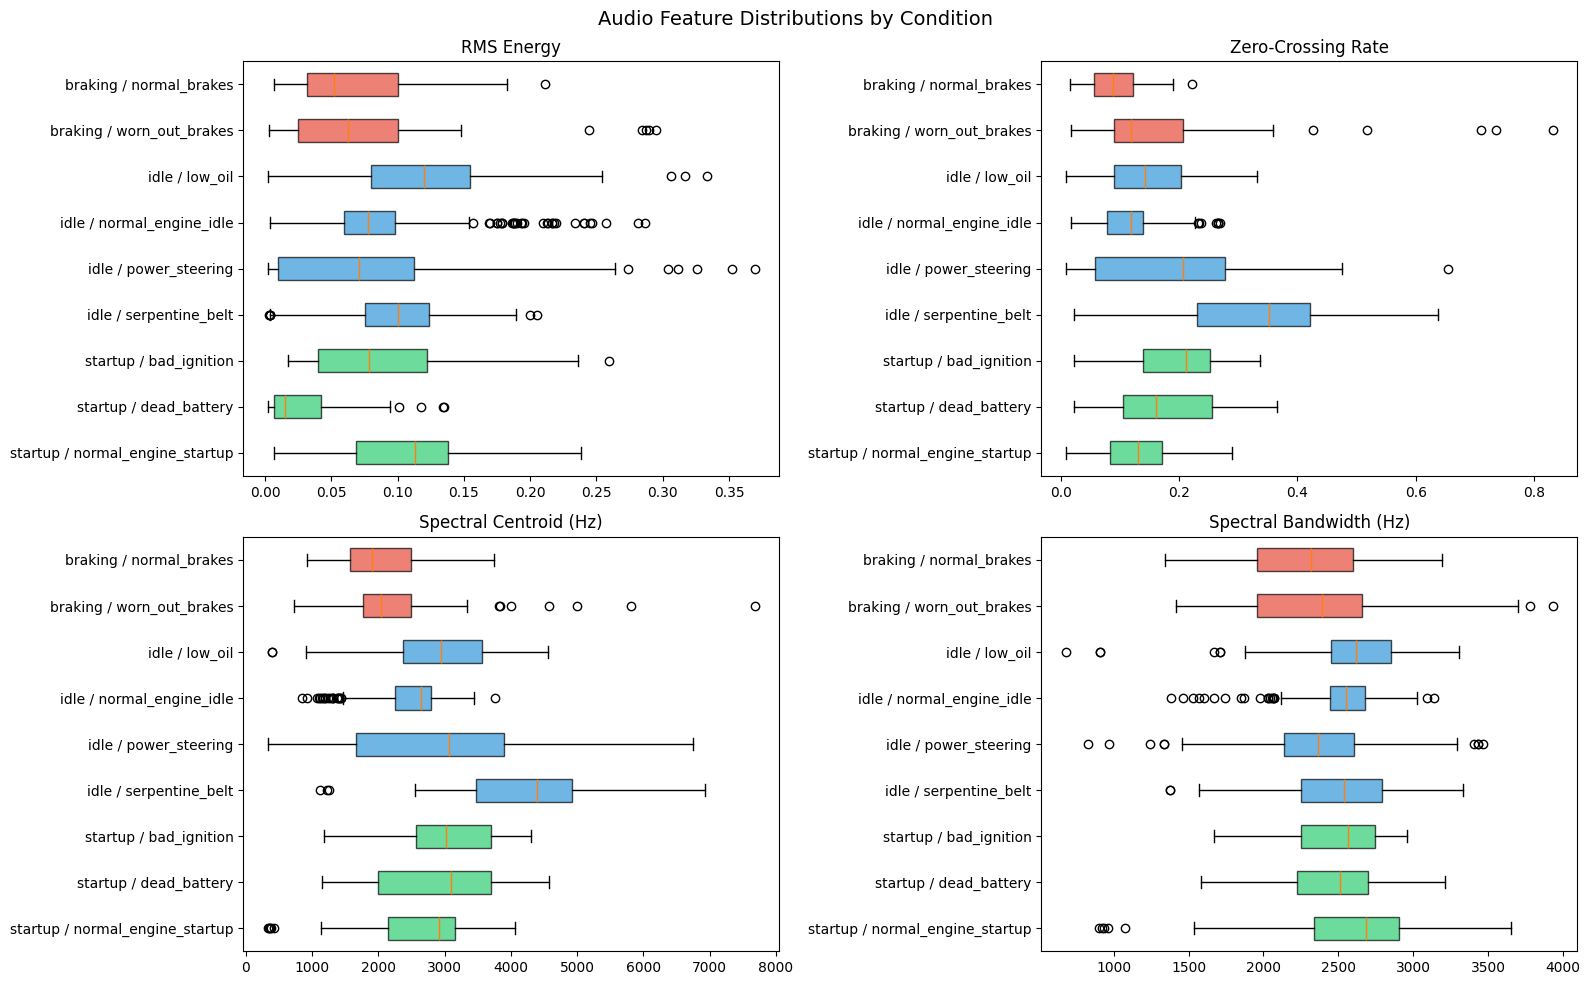

In [11]:
# --- Cell 9: Feature distributions — box plots comparing conditions ---

# Add a combined label for easier plotting
df_features["label"] = (
    df_features["state"].str.replace(" state", "") + " / " + df_features["condition"]
)

# Filter out combined conditions for cleaner plots
df_plot = df_features[~df_features["condition"].str.startswith("combined")].copy()

feature_cols = ["rms_mean", "zcr_mean", "centroid_mean", "bandwidth_mean"]
feature_names = ["RMS Energy", "Zero-Crossing Rate", "Spectral Centroid (Hz)", "Spectral Bandwidth (Hz)"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, name in zip(axes.flat, feature_cols, feature_names):
    labels_sorted = sorted(df_plot["label"].unique(), reverse=True)
    data = [df_plot[df_plot["label"] == lbl][col].values for lbl in labels_sorted]
    bp = ax.boxplot(data, labels=labels_sorted, patch_artist=True, vert=False)
    ax.set_title(name)
    # Color by state
    for patch, lbl in zip(bp["boxes"], labels_sorted):
        key = lbl.split(" / ")[0]
        patch.set_facecolor(palette.get(key, "#95a5a6"))
        patch.set_alpha(0.7)

fig.suptitle("Audio Feature Distributions by Condition", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# --- Cell 10: Listen to samples — one normal + one fault per state ---
# (Works in Jupyter / VS Code notebook environments)

listen_pairs = [
    ("braking state", "normal_brakes", "worn_out_brakes"),
    ("idle state",    "normal_engine_idle", "serpentine_belt"),
    ("startup state", "normal_engine_startup", "dead_battery"),
]

for state, normal_cond, fault_cond in listen_pairs:
    print(f"\n{'='*60}")
    print(f"  {state.upper()}")
    print(f"{'='*60}")
    for label, cond in [("Normal", normal_cond), ("Fault", fault_cond)]:
        sample = df_files[(df_files["state"] == state) & (df_files["condition"] == cond)].iloc[0]
        y, sr = librosa.load(sample["path"], sr=None)
        print(f"\n  {label}: {cond}  ({sample['duration_s']:.1f}s)")
        display(ipd.Audio(y, rate=sr))


  BRAKING STATE

  Normal: normal_brakes  (1.5s)



  Fault: worn_out_brakes  (1.5s)



  IDLE STATE

  Normal: normal_engine_idle  (1.5s)



  Fault: serpentine_belt  (1.5s)



  STARTUP STATE

  Normal: normal_engine_startup  (1.7s)



  Fault: dead_battery  (1.7s)


## Summary

Key takeaways from this exploration:

1. **Dataset structure**: 3 operational states, 9 primary conditions, plus 4 combined-fault categories under idle state.
2. **Class balance**: The idle state has significantly more samples (especially `normal_engine_idle` at ~264 files) compared to braking (~77 each) and startup (~57-62 each). The combined-fault categories also have ~107 files each.
3. **Audio properties**: Check the summary above for sample rates, durations, and channel counts across the dataset.
4. **Visual differences**: Mel-spectrograms show distinct frequency patterns between normal and faulty conditions.
5. **Feature separability**: Basic audio features (RMS, ZCR, spectral centroid, bandwidth) already show some separation between conditions in the box plots.

### Next steps
- Extract richer features (MFCCs, chroma, spectral contrast) for modeling
- Decide whether to treat combined-fault categories as separate classes or multi-label targets
- Address class imbalance (oversampling, augmentation, or weighted loss)
- Build train/val/test splits stratified by condition